## Our Framework Evaluation with Wisig Dataset

Dataset: [link](https://cores.ee.ucla.edu/downloads/datasets/wisig/)

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
import cfo_utils
import utils
import matplotlib.pyplot as plt
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI
from dataset_preparation import ChannelIndSpectrogram
import random
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

os.environ['TF_DETERMINISTIC_OPS'] = '1'

DATASET_NAME =           DatasetAPI.DATASET_WISIG
RX_NODES =               [DatasetAPI.RX_1]
ROOT_DIRECTORY =         '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY =   '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting'
MATLAB_SESSION_ID =      'fp_workflow'
AUG_ON =                 False

DATA_CONFIG = {
    'dataset_name':      DATASET_NAME,
    'frame_count_train': 1000, # 200 for v2, 500 for v4, 500 for wisig
    'frame_count_epoch': 100,
    'samples_count':     400
}

AUG_CONFIG = {
    'multiplier':        5,
    't_rms_bounds':      matlab.double([1, 2]),
    'd_f_bounds':        matlab.double([0, 1]),
    'k_factor_bounds':   matlab.double([0, 1]),
    'awgn':              matlab.double([0, 1]),
}

MODEL_CONFIG = {
    'batch_size':        32,
    'loss_type':         'triplet_loss', 'alpha': 0.5,
    # 'loss_type':         'quadruplet_loss', 'alpha': 1.2,
    'fp_len':            512,
    'row':               100,
    'enable_ind':        False
}

extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
fp_api = FingerprintingAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
eval_api = EvaluationAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

2024-10-31 01:13:14.920379: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-31 01:13:14.920435: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-31 01:13:14.921958: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-31 01:13:14.928875: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-31 01:13:15.602782: W tensorflow/compiler/tf2

In [2]:
enable_training = False

if enable_training: 
    # models, histories = fp_api.train_models()
    models, histories = fp_api.train_models_wisig(multiday=False, compensate_cfo=True)

    history = histories[RX_NODES[0]]

    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
else: 
    models = fp_api.load_models()

model = models[RX_NODES[0]]

Devices for training: 33
Devices for testing: 5


2024-10-31 01:13:17.582294: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79060 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-10-31 01:13:17.583721: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79060 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-10-31 01:13:17.585028: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79060 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


Devices for training: 33
Devices for testing: 5
Enrollment devices: [266, 394, 269, 398, 159]
Removing CFO from equalized signal.
Removing CFO from equalized signal.
Removing CFO from equalized signal.
Removing CFO from equalized signal.
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.


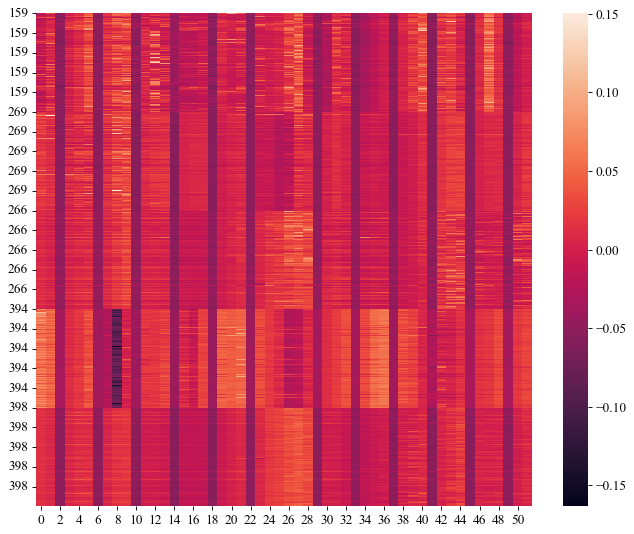

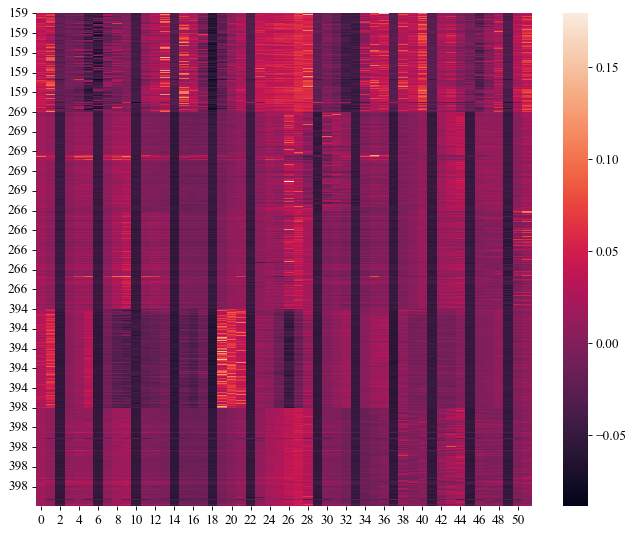

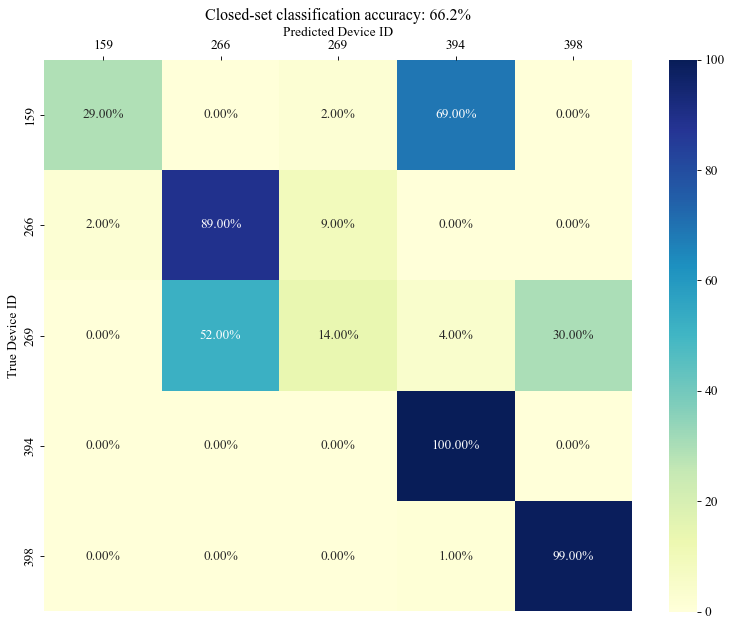

Closed-set classification accuracy: 66.2%


In [31]:
CFO_COMP_ON = True
RSSI_FILTERING_ON = False
CFO_FILTERING_ON = False

def combine_datasets(datas, labels):
    data = np.concatenate(datas, axis=0)
    label = np.concatenate(labels, axis=0)
    return data, label

# 1. Retrieve information about the WiSig dataset (device IDs, paths, etc)
dataset_train_path, dataset_epoch_paths, _, node_ids_train, node_ids_epoch, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], RX_NODES[0], None)
# Non-equalized, Day 2
# dataset_train_paths = [dataset_train_path, '/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_08/Train/node1-1_non_eq_train.h5']
# Equalized, Day 2
dataset_train_paths = [dataset_train_path, '/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_08/Train/node1-1_eq_train.h5']

# Let's show devices used for enrollment / identification
print(f'Enrollment devices: {list(set(node_ids_epoch))}')

# 2. Prepare signal & labels for enrollment subset (epoch #0)
data_train_1, labels_train_1, _ = dataset_api.load_raw_dataset_wisig_eq(dataset_train_paths[0], shuffle=False, compensate_cfo=CFO_COMP_ON)
data_epoch_1, labels_epoch_1, _ = dataset_api.load_raw_dataset_wisig_eq(dataset_epoch_paths[0], shuffle=False, compensate_cfo=CFO_COMP_ON)
data_enroll, label_enroll = combine_datasets(datas=[data_train_1, data_epoch_1], labels=[labels_train_1, labels_epoch_1])
data_enroll, label_enroll, _ = dataset_api.filter_dataset(data_enroll, label_enroll, None, 
                                                          dev_range=node_ids_epoch, 
                                                          pkt_range=np.arange(400, 500))
data_enroll = data_enroll[:, 0:DATA_CONFIG['samples_count']]
if RSSI_FILTERING_ON:
    data_enroll = ChannelIndSpectrogram()._normalization(data_enroll)
    rssi_enroll = np.array([utils.calculate_preamble_rssi(data_enroll[i, :]) for i in range(data_enroll.shape[0])])
    data_enroll, label_enroll, rssi_enroll_final, filtered_idx = dataset_api.filter_frames_by_rssi(data_enroll, label_enroll, rssi_enroll, 100, show_dist=False)
    # plt.figure(figsize=(10, 8), dpi=80)
    # plt.scatter(range(len(rssi_enroll)), rssi_enroll, label='Day 1 before')
    # plt.scatter(filtered_idx, rssi_enroll_final, label='Day 1 after')
    # plt.legend()
    # plt.ylim(-10, 5)
    # plt.show()
if CFO_FILTERING_ON:
    data_enroll, label_enroll, _ = dataset_api.filter_frames_by_cfo(data_enroll, label_enroll, None, show=False)

# 3. Prepare signal & labels for identification subset (epoch #1)
data_train_2, labels_train_2, _ = dataset_api.load_raw_dataset_wisig_eq(dataset_train_paths[1], shuffle=False, compensate_cfo=CFO_COMP_ON)
data_epoch_2, labels_epoch_2, _ = dataset_api.load_raw_dataset_wisig_eq(dataset_epoch_paths[1], shuffle=False, compensate_cfo=CFO_COMP_ON)
data_id, label_id = combine_datasets(datas=[data_train_2, data_epoch_2], labels=[labels_train_2, labels_epoch_2])
data_id, label_id, _ = dataset_api.filter_dataset(data_id, label_id, None, 
                                                          dev_range=node_ids_epoch, 
                                                          pkt_range=np.arange(400, 500))
data_id = data_id[:, 0:DATA_CONFIG['samples_count']]
if RSSI_FILTERING_ON:
    data_id = ChannelIndSpectrogram()._normalization(data_id)
    rssi_id = np.array([utils.calculate_preamble_rssi(data_id[i, :]) for i in range(data_id.shape[0])])
    data_id, label_id, rssi_id_final, filtered_idx = dataset_api.filter_frames_by_rssi(data_id, label_id, rssi_id, 100, show_dist=False)
    # plt.figure(figsize=(10, 8), dpi=80)
    # plt.scatter(range(len(rssi_id)), rssi_id, label='Day 2 before')
    # plt.scatter(filtered_idx, rssi_id_final, label='Day 2 after')
    # plt.legend()
    # plt.ylim(-10, 5)
    # plt.show()
if CFO_FILTERING_ON:
    data_id, label_id, _ = dataset_api.filter_frames_by_cfo(data_id, label_id, None, show=False)

# 4. Perform closed-set data evaluation
accuracy, real, pred = eval_api.evaluate_closed_set_knn(
    model, data_enroll, label_enroll, data_id, label_id, 
    model_config=MODEL_CONFIG, k=10, fig_path='multirx_closed_set.eps')
print(f'Closed-set classification accuracy: {np.round(accuracy*100, 2)}%')

<!--  -->

### Little Experiment with CFO on WiSig

Let's evaluate what the CFO values look like for different devices across days (using raw non-equalized data). 

If there's major volatility -- maybe there's correlation between that volatility and devices that are often misclassified?..

In [8]:
compensate_cfo = True

data_raw_11, label_raw_11, _ = dataset_api.load_raw_dataset_wisig_eq(
    path='/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_01/Train/node1-1_eq_train.h5', 
    shuffle=False, compensate_cfo=compensate_cfo)
data_raw_12, label_raw_12, _ = dataset_api.load_raw_dataset_wisig_eq(
    path='/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_01/Test/eq_epoch_2021-03-01_00-00-00.h5', 
    shuffle=False, compensate_cfo=compensate_cfo)
data_raw_21, label_raw_21, _ = dataset_api.load_raw_dataset_wisig_eq(
    path='/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_08/Train/node1-1_eq_train.h5', 
    shuffle=False, compensate_cfo=compensate_cfo)
data_raw_22, label_raw_22, _ = dataset_api.load_raw_dataset_wisig_eq(
    path='/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_08/Test/eq_epoch_2021-03-08_00-00-00.h5', 
    shuffle=False, compensate_cfo=compensate_cfo)

data_raw_1, label_raw_1 = combine_datasets(datas=[data_raw_11, data_raw_12], labels=[label_raw_11, label_raw_12])
data_raw_2, label_raw_2 = combine_datasets(datas=[data_raw_21, data_raw_22], labels=[label_raw_21, label_raw_22])
    

Removing CFO from equalized signal.
Removing CFO from equalized signal.
Removing CFO from equalized signal.
Removing CFO from equalized signal.


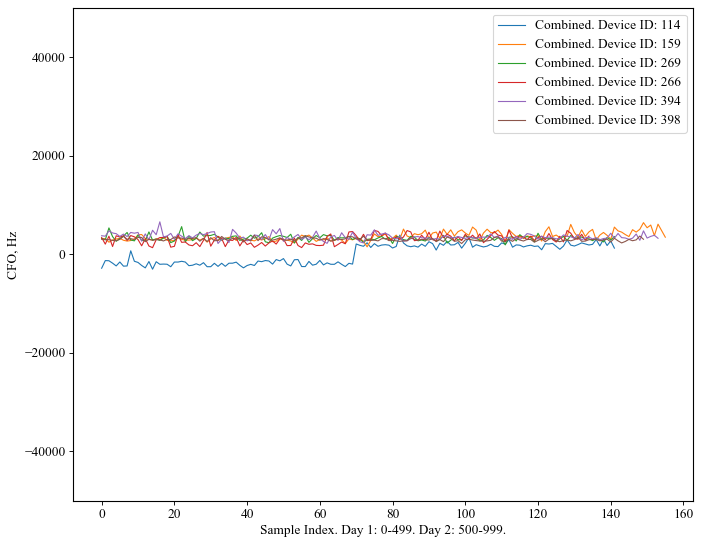

In [26]:
# device_ids = [9, 25, 84, 133, 142]
# device_ids = [9, 11, 15, 17, 25, 38, 52, 57, 60, 69, 80, 84, 129]
device_ids = [114, 159, 269, 266, 394, 398]
# device_ids = [269, 394, 398]

plt.figure(figsize=(10, 8), dpi=80)
for device_id in device_ids:
    data_raw_1_dev, label_raw_1_dev, _ = dataset_api.filter_dataset(data_raw_1, label_raw_1, None, dev_range=[device_id], pkt_range=np.arange(400, 500))
    data_raw_2_dev, label_raw_2_dev, _ = dataset_api.filter_dataset(data_raw_2, label_raw_2, None, dev_range=[device_id], pkt_range=np.arange(400, 500))

    data_raw_1_dev, _, _ = dataset_api.filter_frames_by_cfo(data_raw_1_dev, label_raw_1_dev, None, show=False)
    data_raw_2_dev, _, _ = dataset_api.filter_frames_by_cfo(data_raw_2_dev, label_raw_2_dev, None, show=False)

    cfo_1 = cfo_utils.extract_data_cfo(data_raw_1_dev)
    cfo_2 = cfo_utils.extract_data_cfo(data_raw_2_dev)
    cfo_comb = np.vstack((cfo_1, cfo_2))
    
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 0], label=f"Coarse. Device ID: {device_id}")
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 1], label=f"Fine. Device ID: {device_id}")
    plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 0] + cfo_comb[:, 1], label=f"Combined. Device ID: {device_id}")

plt.legend()
plt.ylim(-50e3, 50e3)
plt.xlabel('Sample Index. Day 1: 0-499. Day 2: 500-999.')
plt.ylabel('CFO, Hz')
plt.show()